In [36]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, Flatten, MaxPooling2D, BatchNormalization, Dropout
import numpy as np
import matplotlib.pyplot as plt

In [37]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

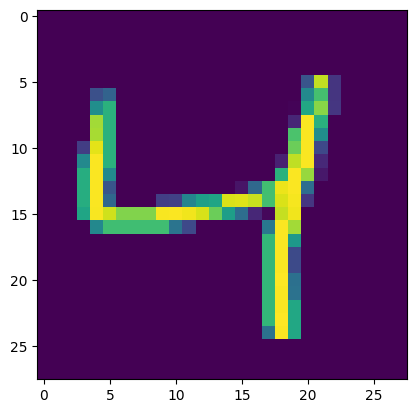

In [38]:
plt.imshow(x_train[2])

In [39]:
print(len(x_train))
len(x_test)

60000


10000

In [40]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [41]:
# Add channel dimension
x_train = x_train[..., tf.newaxis]
x_test = x_test[..., tf.newaxis]


In [42]:
model=Sequential()
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2),padding="valid",strides=2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(10,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [43]:
model.compile(optimizer='adam',loss='SparseCategoricalCrossentropy',metrics=['accuracy'])

In [44]:
model.fit(x_train,y_train,epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9090 - loss: 0.3005
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 72s 17ms/step - accuracy: 0.9839 - loss: 0.0522
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - accuracy: 0.9907 - loss: 0.0322
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 30s 16ms/step - accuracy: 0.9935 - loss: 0.0208
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 27s 14ms/step - accuracy: 0.9963 - loss: 0.0123


In [45]:
model.save("mnist_model.h5")